# Life cycle of Machine Learning Project

- Data Collection
- Data Checks to perfrom
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model


## 1) Data Collection

### **Note:** **This is a fictional dataset. It is not from a real context and the dataset does not represent real people. The puropose of this data set is to teach data science and statistics, but if it is not clearly marked as fictional, then it will miseducate students.**


- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977

- The data consists of 8 column and 1000 rows


### 1.1 Import Data and Required Packages

#### Importing Pandas, Numpy, Matplotlib, Seaborn and Warnings Library.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings 
#warnings.filterwarnings('ignore')


#### Import CSV Data as Pandas DataFrame

In [2]:
df=pd.read_csv('data/stud.csv')

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
#shape of dataset
df.shape

(1000, 8)

### 1.2 Dataset information

- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school, some high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score


## 2. Data Checks to perform

- Check missing values
- Check duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 2.1 Check missing values

In [7]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

#### There are no missing values in the data set

### 2.2 Check duplicates

In [9]:
df.duplicated().sum()

np.int64(0)

#### There are no duplicates in the data set

### 2.3 Check data types

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


### 2.4 Checking the number of unique values of each column

In [11]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### 2.5 Check statistics of data set

In [12]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### 2.6 Exploring Data

In [14]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [19]:
print("Categories in 'gender' variable:  ", end="")
print(df['gender'].unique())
print("Categories in 'race_ethnicity' variable:  ", end="")
print(df['race_ethnicity'].unique())
print("Categories in 'parental_level_of_education' variable:  ", end="")
print(df['parental_level_of_education'].unique())
print("Categories in 'lunch' variable:  ", end="")
print(df['lunch'].unique())
print("Categories in 'test_preparation_course' variable:  ", end="")
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:  <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race_ethnicity' variable:  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental_level_of_education' variable:  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test_preparation_course' variable:  <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [21]:
df['gender'].dtype=='str'

True

In [31]:
# define numerical & categorical columns
from pandas.api.types import is_numeric_dtype
numeric_features = [feature for feature in df.columns if is_numeric_dtype(df[feature])==True]
categorical_features=[feature for feature in df.columns if not is_numeric_dtype(df[feature])]

print(f"There are {len(numeric_features)} numerical features:{numeric_features}")
print(f"There are {len(categorical_features)} categorical_features:{categorical_features}")

There are 3 numerical features:['math_score', 'reading_score', 'writing_score']
There are 5 categorical_features:['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [32]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### 2.7 Adding columns for "Total Score" and "Average"

In [42]:
#make copy of dataset to modify/feature engineering
df_temp=df.copy()
df_temp.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [43]:
df_temp['total_score'] = df_temp['math_score'] + df_temp['reading_score'] + df_temp['writing_score']
df_temp['average']=df_temp['total_score']/3
df_temp.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [53]:
reading_full=(df_temp["reading_score"]==100).sum()
writing_full=(df["writing_score"]==100).sum()
math_full=(df_temp["math_score"]==100).sum()

print(f'Number of students with full marks in reading: {reading_full}')
print(f'Number of students with full marks in writing: {writing_full}')
print(f'Number of students with full marks in math: {math_full}')


Number of students with full marks in reading: 17
Number of students with full marks in writing: 14
Number of students with full marks in math: 7


In [54]:
reading_less_20=(df_temp["reading_score"]<20).sum()
writing_less_20=(df["writing_score"]<20).sum()
math_less_20=(df_temp["math_score"]<20).sum()

print(f'Number of students with full marks in reading: {reading_less_20}')
print(f'Number of students with full marks in writing: {writing_less_20}')
print(f'Number of students with full marks in math: {math_less_20}')


Number of students with full marks in reading: 1
Number of students with full marks in writing: 3
Number of students with full marks in math: 4


## 3. Data Visualization

### 3.1 Visualize average score distribution

- Histogram
- Kernel Distribution Function (KDE)

<Axes: xlabel='average', ylabel='Count'>

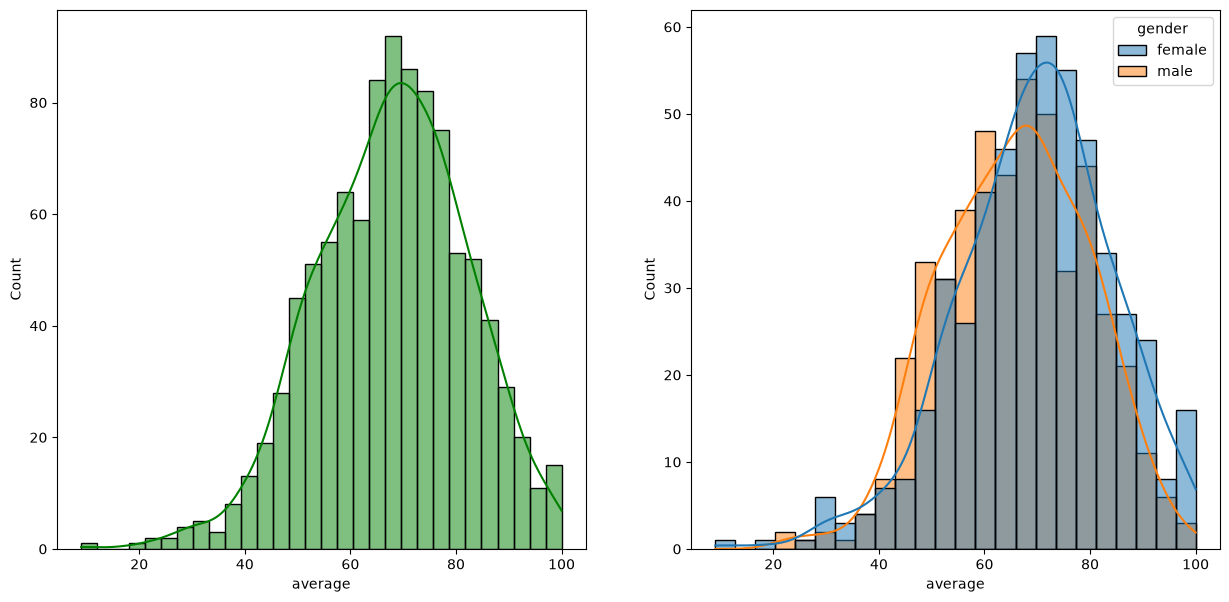

In [62]:
fig, ax=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df_temp,x='average', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df_temp, x='average', kde=True, hue='gender')

<Axes: xlabel='total_score', ylabel='Count'>

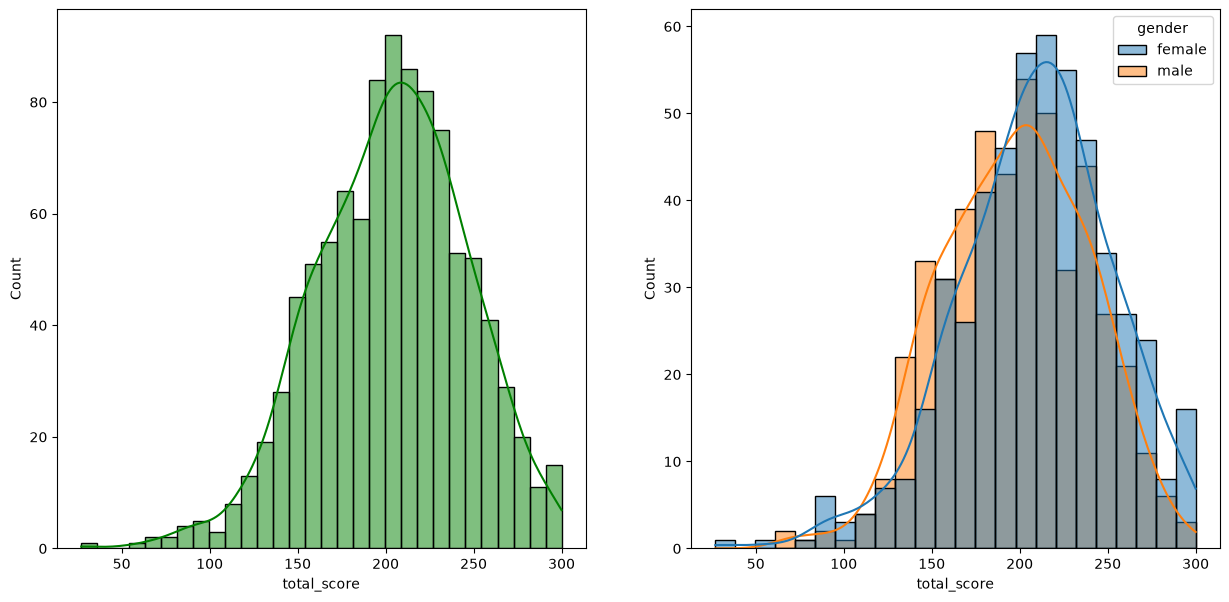

In [63]:
fig, ax=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df_temp,x='total_score', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df_temp, x='total_score', kde=True, hue='gender')

<Axes: xlabel='average', ylabel='Count'>

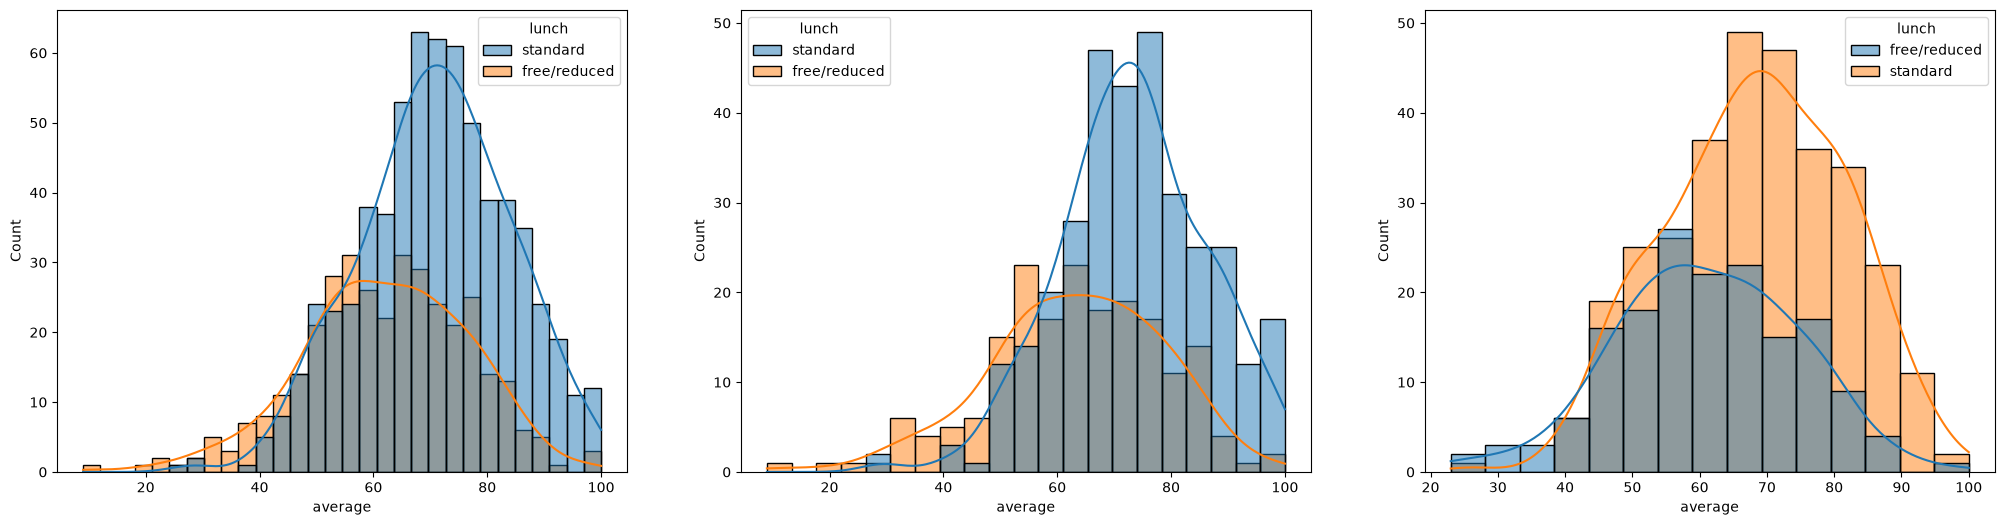

In [68]:
plt.subplots(1,3, figsize=(25, 6))
plt.subplot(131)
sns.histplot(data=df_temp, x='average', bins=30, kde=True, hue='lunch')
plt.subplot(132)
sns.histplot(data=df_temp[df_temp['gender']=='female'],x='average', kde=True, hue='lunch')
plt.subplot(133)
sns.histplot(data=df_temp[df_temp['gender']=='male'], x='average', kde=True, hue='lunch' )